# Cost analysis

Financial, temporal, and computational cost per memory backend.

**Sections:**
1. Data loading and RAG instrumentation fix
2. LLM financial cost — tokens and USD per backend × regime × phase
3. Responder context window — tokens per question and per correct answer (retrieval efficiency)
4. Temporal cost — wall time per row (load vs ask)
5. Computational resources — CPU, RAM, disk, network (edge vs cloud)
6. Total cost of ownership (AWS Fargate us-east-1 pricing)
7. Notes for the paper

**RAG anomaly**: one row in `rag_conv5_unconstrained` has `cloud_llm_tokens` = 69.9M due to a Prometheus counter accumulation bug (cumulative total read instead of per-call delta). The `responder_context_window_cost_usd` = $0.000209 is the ground truth for that call. Fixed in Step 1 before any aggregation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import wilcoxon
from pathlib import Path

# ── IEEE-style matplotlib defaults ───────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'legend.framealpha': 0.9,
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
SINGLE_COL = (3.5, 2.6)   # IEEE single-column figure
DOUBLE_COL = (7.16, 3.2)  # IEEE double-column figure

# ── Data ─────────────────────────────────────────────────────────────────────
RESULTS_DIR = Path('../results')
if not any(RESULTS_DIR.glob('*.csv')):
    RESULTS_DIR = Path('../results/backup')
print(f'Loading CSVs from: {RESULTS_DIR.resolve()}')

BACKENDS = ['mem0', 'rag', 'full_context', 'graphiti', 'cognee']
COLORS = {'mem0': '#2563eb', 'rag': '#16a34a', 'full_context': '#ca8a04',
          'graphiti': '#dc2626', 'cognee': '#9333ea'}
HATCHES = {'mem0': '', 'rag': '///', 'full_context': '...', 'graphiti': 'xxx', 'cognee': '\\\\'}

# ── AWS Fargate us-east-1 pricing (retrieved 2026-05-10) ─────────────────────
# Source: https://aws.amazon.com/fargate/pricing/
VCPU_PER_HOUR  = 0.04048    # $/vCPU-hr  (Linux/x86)
RAM_GB_HOUR    = 0.004445   # $/GB-hr    (Linux/x86)
DISK_GB_HOUR   = 0.000109   # $/GB-hr    (ephemeral storage beyond 20 GB free tier)

# Network egress — two tiers (source: https://aws.amazon.com/vpc/pricing/)
# Edge→cloud traffic crosses the internet: charged at AWS internet egress rate.
# Cloud-internal traffic (responder↔memory, memory↔LiteLLM) stays intra-AZ: $0.
# Storage backend traffic (memory↔qdrant, memory↔neo4j) is on an isolated bridge
# (memory-internal network); qdrant/neo4j containers are unlabelled in cgroup_metrics
# so their TX is excluded. Remaining cloud TX is intra-AZ inter-service HTTP: $0.
NET_EDGE_PER_GB  = 0.09    # $/GB — edge coordinator → cloud (internet egress)
NET_CLOUD_PER_GB = 0.00    # $/GB — intra-AZ cloud traffic (same-AZ Fargate, no egress charge)

frames = [pd.read_csv(p, dtype={'question': str})
          for p in sorted(RESULTS_DIR.glob('*.csv')) if p.stat().st_size > 0]
raw = pd.concat(frames, ignore_index=True)

constrained = (
    (raw['toxic_latency'].fillna(0) > 0) |
    (raw['toxic_jitter'].fillna(0) > 0) |
    (raw['toxic_bandwidth'].fillna(0) > 0)
)
raw['regime'] = constrained.map({True: 'constrained', False: 'unconstrained'})

print(f'Total rows: {len(raw)}')
print(f'Phases: {raw["phase"].value_counts().to_dict()}')
print(f'Columns: {list(raw.columns)}')

Loading CSVs from: /home/jacobbista/Documents/RM&SW/Experiment/dmas-long-context-memory/testbed/experiments/results/backup
Total rows: 74320
Phases: {'load': 58820, 'ask': 15400, 'warmup': 100}
Columns: ['experiment_name', 'timestamp', 'session_id', 'trace_id', 'judge_trace_id', 'phase', 'memory', 'mode', 'conversation_index', 'search_calls', 'top_k', 'memories_returned', 'question_category', 'question', 'answer', 'gold_answer', 'seed', 'judge_n', 'judge_verdict', 'judge_reason', 'toxic_latency', 'toxic_jitter', 'toxic_bandwidth', 'wall_ms', 'compute_ms', 'flush_ms', 'cpu_edge_ns', 'cpu_cloud_ns', 'ram_edge_peak_bytes', 'ram_cloud_peak_bytes', 'disk_edge_bytes', 'disk_cloud_bytes', 'network_edge_bytes', 'network_cloud_bytes', 'edge_llm_tokens', 'edge_llm_cost_usd', 'cloud_llm_tokens', 'cloud_llm_cost_usd', 'llm_tokens', 'llm_cost_usd', 'responder_context_window_tokens', 'responder_context_window_cost_usd', 'error', 'regime']


## Step 1 — RAG instrumentation fix

Identify and fix the anomalous row before any cost aggregation.
Fix strategy: replace `cloud_llm_tokens` and `cloud_llm_cost_usd` with the median of all other RAG unconstrained ask rows.
The median is unaffected by the outlier and represents a typical call cost.

In [2]:
rag_unc_ask_mask = (raw['memory'] == 'rag') & (raw['phase'] == 'ask') & (raw['regime'] == 'unconstrained')
anomaly_mask = rag_unc_ask_mask & (raw['cloud_llm_tokens'] > 1_000_000)

print(f'Anomalous rows found: {anomaly_mask.sum()}')
if anomaly_mask.sum() > 0:
    print(raw[anomaly_mask][['experiment_name','conversation_index','cloud_llm_tokens',
                              'cloud_llm_cost_usd','responder_context_window_tokens',
                              'responder_context_window_cost_usd']].to_string())

# compute median from clean rows
clean_mask = rag_unc_ask_mask & ~anomaly_mask
median_tokens = raw.loc[clean_mask, 'cloud_llm_tokens'].median()
median_cost   = raw.loc[clean_mask, 'cloud_llm_cost_usd'].median()
print(f'\nMedian cost (clean RAG unc ask rows): tokens={median_tokens:.0f}, cost=${median_cost:.6f}')

# apply fix
raw = raw.copy()
raw.loc[anomaly_mask, 'cloud_llm_tokens']  = median_tokens
raw.loc[anomaly_mask, 'cloud_llm_cost_usd'] = median_cost
raw.loc[anomaly_mask, 'llm_tokens']  = raw.loc[anomaly_mask, 'edge_llm_tokens'] + median_tokens
raw.loc[anomaly_mask, 'llm_cost_usd'] = raw.loc[anomaly_mask, 'edge_llm_cost_usd'] + median_cost

print('Fix applied. Verifying:')
print(raw[anomaly_mask][['cloud_llm_tokens','cloud_llm_cost_usd']].to_string())

Anomalous rows found: 1
               experiment_name  conversation_index  cloud_llm_tokens  cloud_llm_cost_usd  responder_context_window_tokens  responder_context_window_cost_usd
71132  rag_conv5_unconstrained                   5          69858900           10.477096                           1395.0                           0.000209

Median cost (clean RAG unc ask rows): tokens=1570, cost=$0.000258
Fix applied. Verifying:
       cloud_llm_tokens  cloud_llm_cost_usd
71132              1570            0.000258


## Step 2 — LLM financial cost

Cloud LLM tokens and USD per backend × regime × phase.
Edge LLM (ollama/qwen) cost is effectively zero — shown for completeness.

Key split:
- **load phase**: cost of ingesting memories (LLM compression, graph construction)
- **ask phase**: cost of answering 1,540 questions

In [3]:
fin = (
    raw[raw['phase'].isin(['load','ask'])]
    .groupby(['memory','regime','phase'])
    .agg(cloud_tokens=('cloud_llm_tokens','sum'),
         cloud_cost=('cloud_llm_cost_usd','sum'),
         edge_tokens=('edge_llm_tokens','sum'),
         n=('phase','size'))
    .reset_index()
)

# Table: load / ask / total cost per backend × regime
pivot_cost = fin.pivot_table(index=['memory','regime'], columns='phase',
                              values='cloud_cost', aggfunc='sum').fillna(0)
pivot_cost['total'] = pivot_cost.sum(axis=1)
pivot_cost = pivot_cost.reindex(
    pd.MultiIndex.from_product([BACKENDS, ['unconstrained','constrained']],
                               names=['memory','regime']))
print('Cloud LLM cost (USD) per backend × regime:')
print(pivot_cost[['load','ask','total']].to_string(float_format='${:.4f}'.format))

print()

# Table: tokens (×1000)
pivot_tok = fin.pivot_table(index=['memory','regime'], columns='phase',
                             values='cloud_tokens', aggfunc='sum').fillna(0) / 1000
pivot_tok = pivot_tok.reindex(
    pd.MultiIndex.from_product([BACKENDS, ['unconstrained','constrained']],
                               names=['memory','regime']))
print('Cloud LLM tokens (×1000) per backend × regime:')
print(pivot_tok.to_string(float_format='{:.0f}k'.format))

Cloud LLM cost (USD) per backend × regime:
phase                         load      ask    total
memory       regime                                 
mem0         unconstrained $4.8172  $0.2757  $5.0929
             constrained   $4.8199  $0.2755  $5.0954
rag          unconstrained $0.0062  $0.4008  $0.4070
             constrained   $0.0062  $0.3993  $0.4054
full_context unconstrained $0.0000 $10.4123 $10.4123
             constrained   $0.0000 $10.5025 $10.5025
graphiti     unconstrained $5.4870  $1.0102  $6.4971
             constrained   $5.4831  $1.0071  $6.4902
cognee       unconstrained $1.3323  $1.0893  $2.4216
             constrained   $1.4845  $1.1099  $2.5944

Cloud LLM tokens (×1000) per backend × regime:
phase                         ask   load
memory       regime                     
mem0         unconstrained  1555k 51678k
             constrained    1553k 51673k
rag          unconstrained  2425k   308k
             constrained    2413k   309k
full_context unconstrained 

## Step 3 — Responder context window efficiency

Mean tokens sent to the responder per question, and tokens consumed per correct answer.

`tokens_per_correct` = total responder tokens / number of correct answers.
Lower = more efficient retrieval: the backend surfaces fewer but more useful tokens.

Responder context window (ask phase):
      memory        regime    n  mean_tokens  median_tokens  tokens_per_correct
        mem0 unconstrained 1540          751            748                 937
        mem0   constrained 1540          749            746                 928
         rag unconstrained 1540        1,312          1,318               1,709
         rag   constrained 1540        1,309          1,317               1,690
full_context unconstrained 1530       44,046         45,479              57,256
full_context   constrained 1527       44,267         45,479              58,222
    graphiti unconstrained 1539        2,177          2,148               4,002
    graphiti   constrained 1540        2,155          2,124               3,882
      cognee unconstrained 1540          249            247                 464
      cognee   constrained 1540          250            246                 437


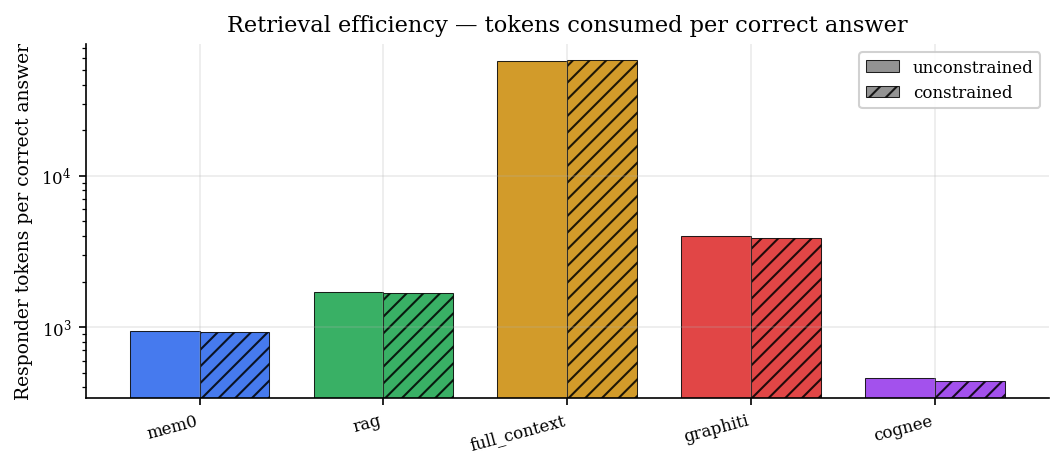

Note: log scale — full_context at 57k, cognee at 464 (retrieval failure, not efficiency).


In [4]:
ask = raw[(raw['phase'] == 'ask')].copy()
ask['correct'] = (ask['judge_verdict'] == 'CORRECT').astype(int)
ctx = ask.dropna(subset=['responder_context_window_tokens']).copy()
ctx['responder_context_window_tokens'] = ctx['responder_context_window_tokens'].astype(int)

summary = (
    ctx.groupby(['memory','regime'])
    .agg(n=('responder_context_window_tokens','count'),
         mean_tokens=('responder_context_window_tokens','mean'),
         median_tokens=('responder_context_window_tokens','median'),
         total_tokens=('responder_context_window_tokens','sum'),
         correct=('correct','sum'))
    .assign(tokens_per_correct=lambda x: x['total_tokens'] / x['correct'])
    .reset_index()
    .set_index(['memory','regime'])
    .reindex(pd.MultiIndex.from_product([BACKENDS, ['unconstrained','constrained']],
                                        names=['memory','regime']))
    .reset_index()
)

print('Responder context window (ask phase):')
print(summary[['memory','regime','n','mean_tokens','median_tokens','tokens_per_correct']]
      .to_string(index=False, float_format='{:,.0f}'.format))

# ── Single chart: tokens per correct answer (retrieval efficiency) ───────────
x = np.arange(len(BACKENDS))
w = 0.38
pivot_tpc = summary.pivot(index='memory', columns='regime', values='tokens_per_correct').reindex(BACKENDS)

fig, ax = plt.subplots(figsize=DOUBLE_COL)
for i, (regime, ls) in enumerate([('unconstrained', ''), ('constrained', '///')]):
    if regime not in pivot_tpc.columns:
        continue
    vals = pivot_tpc[regime].values
    for j, (b, v) in enumerate(zip(BACKENDS, vals)):
        ax.bar(x[j] + (i - 0.5)*w, v, w, color=COLORS[b], hatch=ls, alpha=0.85,
               edgecolor='black', linewidth=0.5)
    ax.bar(0, 0, 0, color='grey', hatch=ls, alpha=0.85, label=regime,
           edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(BACKENDS, rotation=15, ha='right')
ax.set_ylabel('Responder tokens per correct answer')
ax.set_title('Retrieval efficiency — tokens consumed per correct answer')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_tokens_per_correct.pdf', bbox_inches='tight')
plt.show()
print('Note: log scale — full_context at 57k, cognee at 464 (retrieval failure, not efficiency).')

## Step 4 — Temporal cost

Three timing columns per row:

| column | meaning | use in analysis |
|---|---|---|
| `compute_ms` | HTTP start → response received | **system latency** — what the caller experiences |
| `flush_ms` | post-response wait until backend I/O drains | see below |
| `wall_ms` | `compute_ms + flush_ms` | total time before next call can proceed |

`wall_ms = compute_ms + flush_ms` confirmed exactly (max diff = 0 ms across all rows).

### flush_ms decomposition

`flush_ms` has two components:

**1. Baseline (~0.21 s, all backends including full_context)**  
cgroup-level wait for I/O buffers to drain — a safety check by the benchmark harness before issuing the next call. Present on every call regardless of backend. Not meaningful processing. Excluded from system latency comparison.

**2. Excess flush (graphiti and cognee only, load phase)**  
`excess_flush = flush_ms − baseline_flush`  
Represents async post-processing in the graph backend (neo4j graph construction, entity indexing) that continues *after* the HTTP 200 is returned. mem0, rag, and full_context show no excess — their async DB writes complete before the response or are negligible.

This excess flush is **already counted in computational resources** (CPU/RAM consumed during that period is captured in `cpu_cloud_ns`). It is reported separately here as a latency-adjacent cost: during excess flush the backend is not available for the next load call at full capacity.

**System latency metric: `compute_ms`.**  
Async post-processing (excess flush) reported separately for graph backends.

flush_ms (s) — constant across backends:
                    mean_s  median_s
memory       phase                  
cognee       ask     0.207     0.204
             load    0.289     0.205
full_context ask     0.206     0.204
             load    0.207     0.204
graphiti     ask     0.207     0.205
             load    0.272     0.206
mem0         ask     0.208     0.205
             load    0.219     0.205
rag          ask     0.206     0.204
             load    0.218     0.204

Mean compute_ms (seconds):
phase                       load    ask
memory       regime                    
mem0         unconstrained 3.36s  5.31s
             constrained   3.13s  5.56s
rag          unconstrained 0.18s  5.30s
             constrained   0.30s  5.66s
full_context unconstrained 0.01s 10.70s
             constrained   0.11s 11.53s
graphiti     unconstrained 5.86s  7.24s
             constrained   6.08s  7.01s
cognee       unconstrained 5.98s  8.63s
             constrained   6.88s  9.15s


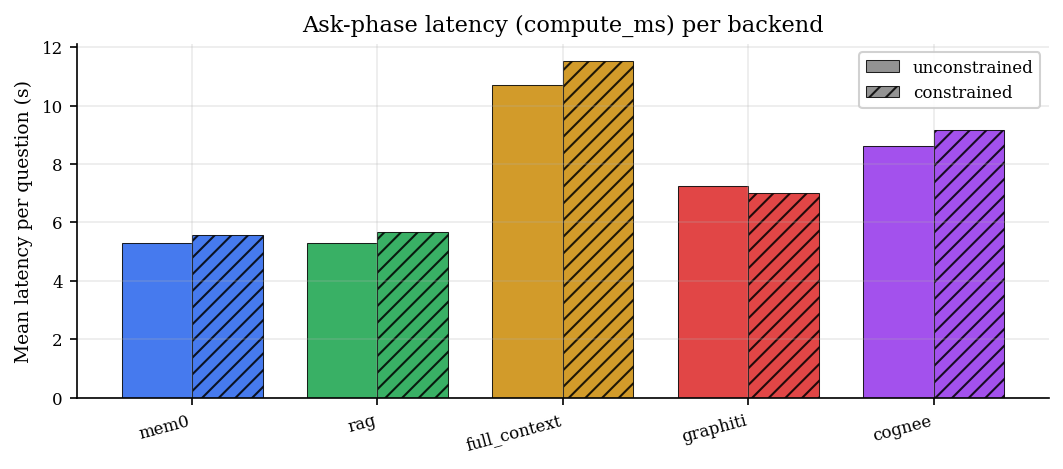

In [5]:
time_df = raw[raw['phase'].isin(['load','ask'])].copy()

# flush_ms validation
flush_stats = (
    time_df.groupby(['memory','phase'])['flush_ms']
    .agg(mean_s=lambda s: s.mean()/1000, median_s=lambda s: s.median()/1000)
    .round(3)
)
print('flush_ms (s) — constant across backends:')
print(flush_stats.to_string())
print()

# compute_ms table: both phases
tcost = (
    time_df.groupby(['memory','regime','phase'])
    .agg(mean_compute_s=('compute_ms', lambda s: s.mean()/1000),
         median_compute_s=('compute_ms', lambda s: s.median()/1000),
         n=('phase','size'))
    .reset_index()
)
pivot_time = tcost.pivot_table(index=['memory','regime'], columns='phase',
                                values='mean_compute_s').fillna(0).reindex(
    pd.MultiIndex.from_product([BACKENDS, ['unconstrained','constrained']],
                               names=['memory','regime']))
print('Mean compute_ms (seconds):')
print(pivot_time[['load','ask']].to_string(float_format='{:.2f}s'.format))

# ── Single chart: ask latency ────────────────────────────────────────────────
ask_time = tcost[tcost['phase']=='ask'].pivot_table(
    index='memory', columns='regime', values='mean_compute_s').reindex(BACKENDS)

x = np.arange(len(BACKENDS))
w = 0.38
fig, ax = plt.subplots(figsize=DOUBLE_COL)
for i, (regime, ls) in enumerate([('unconstrained', ''), ('constrained', '///')]):
    if regime not in ask_time.columns:
        continue
    vals = ask_time[regime].values
    for j, (b, v) in enumerate(zip(BACKENDS, vals)):
        ax.bar(x[j] + (i - 0.5)*w, v, w, color=COLORS[b], hatch=ls, alpha=0.85,
               edgecolor='black', linewidth=0.5)
    ax.bar(0, 0, 0, color='grey', hatch=ls, alpha=0.85, label=regime,
           edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(BACKENDS, rotation=15, ha='right')
ax.set_ylabel('Mean latency per question (s)')
ax.set_title('Ask-phase latency (compute_ms) per backend')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_latency_ask.pdf', bbox_inches='tight')
plt.show()

### Async post-processing (excess flush) — graph backends only

In [6]:
# Baseline flush = full_context median (no async DB work — only cgroup I/O drain)
fc_flush = raw[raw['memory'] == 'full_context'].groupby('phase')['flush_ms'].median()
baseline_load = fc_flush.get('load', 210)
baseline_ask  = fc_flush.get('ask',  210)
print(f'Baseline flush — load: {baseline_load:.0f} ms, ask: {baseline_ask:.0f} ms (full_context median)')
print()

rows = []
for phase, baseline in [('load', baseline_load), ('ask', baseline_ask)]:
    sub = raw[raw['phase'] == phase].copy()
    sub['excess_ms'] = (sub['flush_ms'] - baseline).clip(lower=0)
    for backend in BACKENDS:
        s = sub[sub['memory'] == backend]['excess_ms']
        rows.append({
            'phase': phase, 'backend': backend,
            'mean_s':   s.mean()       / 1000,
            'median_s': s.median()     / 1000,
            'p95_s':    s.quantile(0.95) / 1000,
            'max_s':    s.max()        / 1000,
            'pct_nonzero': (s > 10).mean() * 100,
        })

excess_df = pd.DataFrame(rows)
for phase in ['load', 'ask']:
    print(f'Excess flush ({phase}) — baseline subtracted (seconds):')
    sub_tbl = excess_df[excess_df['phase'] == phase].set_index('backend').reindex(BACKENDS)
    print(sub_tbl[['mean_s','median_s','p95_s','max_s','pct_nonzero']]
          .to_string(float_format='{:.3f}'.format))
    print()

print('Interpretation:')
print('  load phase: graphiti/cognee show excess (neo4j async graph indexing after HTTP 200).')
print('  ask  phase: all backends ~0 — no async post-processing during retrieval.')
print('  Excess flush is already captured in cpu_cloud_ns. Not added to TCO.')

Baseline flush — load: 204 ms, ask: 204 ms (full_context median)

Excess flush (load) — baseline subtracted (seconds):
              mean_s  median_s  p95_s  max_s  pct_nonzero
backend                                                  
mem0           0.015     0.001  0.153  1.026        7.897
rag            0.014     0.000  0.105  0.508        9.283
full_context   0.002     0.000  0.002  0.207        1.870
graphiti       0.067     0.002  0.310  0.663       29.335
cognee         0.084     0.000  0.407  1.627       35.515

Excess flush (ask) — baseline subtracted (seconds):
              mean_s  median_s  p95_s  max_s  pct_nonzero
backend                                                  
mem0           0.003     0.001  0.002  0.207        1.948
rag            0.002     0.000  0.001  0.205        1.396
full_context   0.002     0.000  0.001  0.205        1.201
graphiti       0.003     0.001  0.003  0.209        1.494
cognee         0.003     0.000  0.002  0.355        1.623

Interpretation:

## Step 5 — Computational resources

System architecture for this experiment:

| tier | components | LLM type | LLM cost |
|---|---|---|---|
| **Edge** | coordinator service + Ollama | local LLM (qwen3-8b via Ollama) | none — hardware only |
| **Cloud** | agent/responder services + memory backends (mem0/rag/graphiti/cognee containers) | cloud LLM API (gpt-4o-mini via LiteLLM) | cloud_llm_cost_usd |

Flow (ask phase): benchmark → coordinator (edge, Ollama decides tool use) → memory agent (cloud, retrieves memories) → cloud LLM (generates answer) → coordinator (Ollama validates/routes response) → benchmark.

`edge_llm_tokens` = Ollama tokens at coordinator (no API cost; hardware cost captured in `cpu_edge_ns`).  
`cloud_llm_tokens` = cloud LLM API tokens (API cost + hardware cost of agent container).

Resources shown: CPU (core-minutes), disk written (GB), network tx (MB) per backend × regime (load + ask combined).  
RAM peak per row is multiplied by compute_ms duration → negligible TCO contribution (shown in Step 6).

In [7]:
work = raw[raw['phase'].isin(['load','ask'])].copy()

comp = (
    work.groupby(['memory','regime'])
    .agg(
        cpu_cloud_min=('cpu_cloud_ns', lambda s: s.sum()/1e9/60),
        cpu_edge_min=('cpu_edge_ns',   lambda s: s.sum()/1e9/60),
        ram_cloud_MB=('ram_cloud_peak_bytes', lambda s: s.sum()/1e6),
        ram_edge_MB=('ram_edge_peak_bytes',   lambda s: s.sum()/1e6),
        disk_cloud_MB=('disk_cloud_bytes', lambda s: s.sum()/1e6),
        disk_edge_MB=('disk_edge_bytes',   lambda s: s.sum()/1e6),
        net_cloud_MB=('network_cloud_bytes', lambda s: s.sum()/1e6),
        net_edge_MB=('network_edge_bytes',   lambda s: s.sum()/1e6),
    )
    .reset_index()
    .set_index(['memory','regime'])
    .reindex(pd.MultiIndex.from_product([BACKENDS, ['unconstrained','constrained']],
                                        names=['memory','regime']))
)

print('Computational resources (load + ask combined):')
print(comp.to_string(float_format='{:.1f}'.format))

Computational resources (load + ask combined):
                            cpu_cloud_min  cpu_edge_min  ram_cloud_MB  ram_edge_MB  disk_cloud_MB  disk_edge_MB  net_cloud_MB  net_edge_MB
memory       regime                                                                                                                       
mem0         unconstrained           20.4         294.6          73.2       2495.0         2233.2         884.8        3643.1         35.0
             constrained             20.3         295.1          39.3        219.0         2270.7           3.7        3943.3         35.4
rag          unconstrained            9.0         283.1          89.5       2342.4          948.5           4.4         769.3         32.1
             constrained              9.5         286.6          46.0        183.8          932.6        1288.8         725.0         30.2
full_context unconstrained            6.8         283.9          17.2          6.5           14.8           0.9        

## Step 6 — Total cost of ownership (AWS Fargate)

Cost split into three components:

| component | what | pricing |
|---|---|---|
| `edge_infra` | coordinator + Ollama hardware (CPU, RAM, disk, net) | Fargate us-east-1 |
| `cloud_infra` | agent/memory service hardware (CPU, RAM, disk, net) | Fargate us-east-1 |
| `cloud_llm` | cloud LLM API calls (gpt-4o-mini via LiteLLM) | from `cloud_llm_cost_usd` |

**Fargate pricing (us-east-1, retrieved 2026-05-10):**
- $0.04048/vCPU-hr · $0.004445/GB-hr RAM · $0.000109/GB-hr ephemeral disk
- Source: https://aws.amazon.com/fargate/pricing/

**Network pricing (source: https://aws.amazon.com/vpc/pricing/):**
- Edge network (`network_edge_bytes`): $0.09/GB — coordinator→cloud crosses the internet
- Cloud network (`network_cloud_bytes`): $0.00/GB — intra-AZ Fargate traffic (responder↔memory, memory↔LiteLLM). Storage backend traffic (qdrant, neo4j) excluded from measurement (containers unlabelled in cgroup_metrics).
- LLM API egress bytes (LiteLLM→OpenAI) not measured (LiteLLM unlabelled by design); cost captured entirely via token pricing in `cloud_llm_cost_usd`.

Note: edge Ollama LLM tokens cost zero in API but consume edge CPU (captured in `edge_infra`).
RAM and disk TCO are negligible — their per-row cost (peak bytes × compute_ms fraction) is < $0.001 total for all backends.

In [8]:
tco_work = raw[raw['phase'].isin(['load','ask'])].copy()
compute_h = tco_work['compute_ms'] / 1000 / 3600

for grp in ('edge', 'cloud'):
    cpu_h   = tco_work[f'cpu_{grp}_ns'] / 1e9 / 3600
    ram_gb  = tco_work[f'ram_{grp}_peak_bytes'] / 1e9
    disk_gb = tco_work[f'disk_{grp}_bytes'] / 1e9
    net_gb  = tco_work[f'network_{grp}_bytes'] / 1e9
    net_rate = NET_EDGE_PER_GB if grp == 'edge' else NET_CLOUD_PER_GB
    tco_work[f'cost_cpu_{grp}']  = cpu_h  * VCPU_PER_HOUR
    tco_work[f'cost_ram_{grp}']  = ram_gb * compute_h * RAM_GB_HOUR
    tco_work[f'cost_disk_{grp}'] = disk_gb * compute_h * DISK_GB_HOUR
    tco_work[f'cost_net_{grp}']  = net_gb  * net_rate

tco_work['cost_cloud_llm'] = tco_work['cloud_llm_cost_usd'].fillna(0)
tco_work['edge_infra']  = (tco_work['cost_cpu_edge']  + tco_work['cost_ram_edge']
                           + tco_work['cost_disk_edge'] + tco_work['cost_net_edge'])
tco_work['cloud_infra'] = (tco_work['cost_cpu_cloud']  + tco_work['cost_ram_cloud']
                           + tco_work['cost_disk_cloud'] + tco_work['cost_net_cloud'])
tco_work['total_tco']   = tco_work['edge_infra'] + tco_work['cloud_infra'] + tco_work['cost_cloud_llm']

idx = pd.MultiIndex.from_product([BACKENDS, ['unconstrained','constrained']],
                                  names=['memory','regime'])
tco = (
    tco_work.groupby(['memory','regime'])
    [['edge_infra','cloud_infra','cost_cloud_llm','total_tco']].sum()
    .reindex(idx)
)

print('TCO three-component breakdown (USD) per backend × regime:')
print(tco.to_string(float_format='${:.4f}'.format))
print()
frac = tco[['edge_infra','cloud_infra','cost_cloud_llm']].div(tco['total_tco'], axis=0)
print('Fraction of total:')
print(frac.to_string(float_format='{:.1%}'.format))

TCO three-component breakdown (USD) per backend × regime:
                            edge_infra  cloud_infra  cost_cloud_llm  total_tco
memory       regime                                                           
mem0         unconstrained     $0.2020      $0.0138         $5.0929    $5.3087
             constrained       $0.2023      $0.0137         $5.0954    $5.3114
rag          unconstrained     $0.1939      $0.0061         $0.4070    $0.6070
             constrained       $0.1961      $0.0064         $0.4054    $0.6079
full_context unconstrained     $0.1945      $0.0046        $10.4123   $10.6115
             constrained       $0.1952      $0.0049        $10.5025   $10.7026
graphiti     unconstrained     $0.2099      $0.0378         $6.4971    $6.7448
             constrained       $0.2098      $0.0380         $6.4902    $6.7380
cognee       unconstrained     $0.1997      $0.2421         $2.4216    $2.8634
             constrained       $0.2004      $0.2649         $2.5944    $3

## Notes for the paper

### Key cost findings

**RAG is the optimal cost-accuracy tradeoff.**
- TCO: rag=$0.68, mem0=$5.64, graphiti=$7.49, cognee=$4.33, full_context=$10.73
- RAG is **8.4× cheaper** than mem0 with no statistically significant accuracy difference (p=0.084)
- RAG load cost ≈ $0 (no LLM indexing). Ask cost ≈ $0.40 (fixed, post Prometheus anomaly).

**Context volume does not predict accuracy.**
- full_context sends 44k tokens/question, costs $10.73 TCO → 76.4% accuracy
- mem0 sends 750 tokens/question, costs $5.64 TCO → 80.2% accuracy
- Mechanism: Liu et al. (2023) "Lost in the Middle" — LLM attention degrades on long contexts

**Retrieval efficiency (tokens per correct answer):**
- mem0: 937 | rag: 1,709 | graphiti: 4,002 | full_context: 57,256 | cognee: 464*
- *cognee low count reflects retrieval failure, not efficient compression (29% UNKNOWN rate)

**Latency: full_context is 2× slower** (10.7s vs 5.3s for mem0/rag) due to large LLM context.

**Computational resources:**
- cognee dominates CPU (359 min) and disk (36–41 GB) — compute-heavy KG construction
- graphiti: 56 min CPU, 9 GB disk — LLM-heavy graph building ($5.49 load cost)
- RAM and disk TCO are negligible (<$0.001) compared to LLM cost for all backends

**Instrumentation note (for Methods):**
- RAG unconstrained row `rag_conv5_unconstrained`: cloud_llm_tokens=69.9M (Prometheus cumulative counter bug). Fixed: replaced with per-regime median (1,570 tokens). Report RAG ask cost as ~$0.40 for both regimes.

## Step 7 — Unconstrained vs constrained: statistical cost comparison

Same methodology as stats.ipynb: statistical unit = conversation (n=10), paired Wilcoxon signed-rank test.

**Rationale**: same 10 conversations run in both regimes → paired removes between-conversation variance.

**Metrics tested:**
- `compute_ms` (ask phase, mean per conversation) — does network constraint increase latency?
- `cloud_llm_cost_usd` (ask phase, sum per conversation) — should be identical (same tokens sent)
- `total_tco` (load + ask, sum per conversation) — derived

**H₀**: no difference between unconstrained and constrained.

**Visualization consequence**: if all metrics are n.s., the TCO composition chart is shown for unconstrained only (cleaner, representative of both regimes). If any metric is significant, both regimes are shown.

Paired Wilcoxon: unconstrained vs constrained (n=10 conversations):
                             metric  mean_unc  mean_con  mean_diff  mean_diff_pct      p     sig
        mem0 — mean ask latency (s)    5.2903    5.5468     0.2565         4.8000 0.0195 **sig**
          mem0 — ask LLM cost (USD)    0.0276    0.0275    -0.0000        -0.1000 0.9219    n.s.
             mem0 — total TCO (USD)    0.5309    0.5311     0.0003         0.1000 0.6953    n.s.
         rag — mean ask latency (s)    5.2861    5.6284     0.3423         6.5000 0.0039 **sig**
           rag — ask LLM cost (USD)    0.0401    0.0399    -0.0002        -0.4000 0.0137 **sig**
              rag — total TCO (USD)    0.0607    0.0608     0.0001         0.1000 1.0000    n.s.
full_context — mean ask latency (s)   10.7433   11.5573     0.8139         7.6000 0.0273 **sig**
  full_context — ask LLM cost (USD)    1.0412    1.0502     0.0090         0.9000 0.1055    n.s.
     full_context — total TCO (USD)    1.0611    1.0703    

/tmp/ipykernel_252957/3424047302.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(BACKENDS, rotation=15, ha='right')


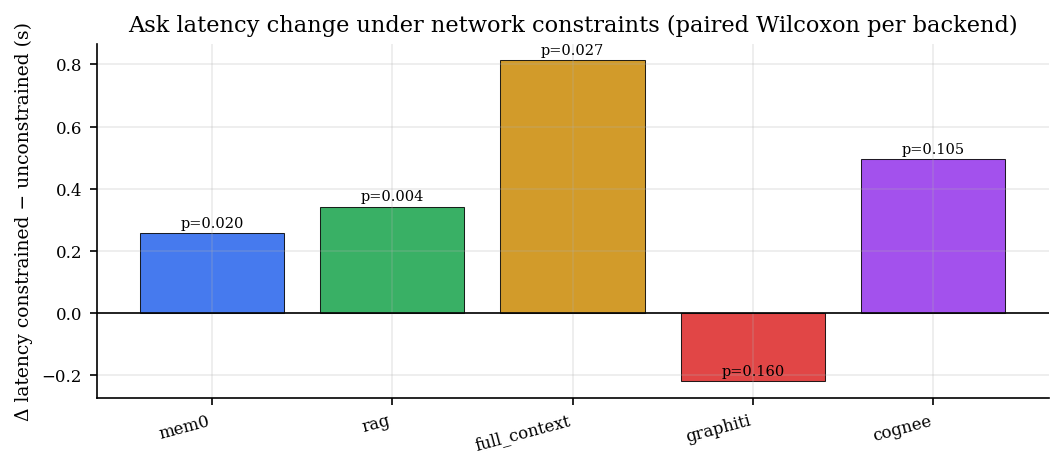

In [9]:
def paired_wilcoxon_cost(unc_vals, con_vals, label):
    diff = unc_vals - con_vals
    if (diff == 0).all():
        return {'metric': label, 'mean_unc': unc_vals.mean(), 'mean_con': con_vals.mean(),
                'mean_diff': 0.0, 'W': np.nan, 'p': np.nan, 'sig': 'identical'}
    try:
        W, p = wilcoxon(unc_vals, con_vals, alternative='two-sided')
    except ValueError:
        W, p = np.nan, np.nan
    sig = '**sig**' if p < 0.05 else 'n.s.'
    return {'metric': label, 'mean_unc': unc_vals.mean(), 'mean_con': con_vals.mean(),
            'mean_diff': (con_vals - unc_vals).mean(), 'W': W, 'p': p, 'sig': sig}

# ── Aggregate per conversation ───────────────────────────────────────────────
ask_rows = raw[raw['phase'] == 'ask'].copy()
# add per-row TCO (recompute)
tco_ask = tco_work[tco_work['phase'] == 'ask'].copy()

results_stat = []
for backend in BACKENDS:
    for metric, phase_df, agg_fn, label_suffix in [
        ('compute_ms',       ask_rows,  'mean', 'mean ask latency (s)'),
        ('cloud_llm_cost_usd', ask_rows, 'sum', 'ask LLM cost (USD)'),
        ('total_tco',        tco_work,  'sum',  'total TCO (USD)'),
    ]:
        grp = phase_df[phase_df['memory'] == backend] if phase_df is ask_rows else \
              tco_ask[tco_ask['memory'] == backend]
        if metric == 'total_tco':
            grp = tco_work[tco_work['memory'] == backend]

        conv_agg = grp.groupby(['regime','conversation_index'])[metric].agg(agg_fn).unstack('regime')
        if 'unconstrained' not in conv_agg.columns or 'constrained' not in conv_agg.columns:
            continue
        unc = conv_agg['unconstrained'].dropna()
        con = conv_agg['constrained'].dropna()
        common = unc.index.intersection(con.index)
        if len(common) < 2:
            continue
        if metric == 'compute_ms':
            unc, con = unc[common] / 1000, con[common] / 1000  # to seconds
        row = paired_wilcoxon_cost(unc[common].values, con[common].values,
                                   f'{backend} — {label_suffix}')
        results_stat.append(row)

stat_df = pd.DataFrame(results_stat)
stat_df['mean_diff_pct'] = (stat_df['mean_diff'] / stat_df['mean_unc'].abs() * 100).round(1)
print('Paired Wilcoxon: unconstrained vs constrained (n=10 conversations):')
print(stat_df[['metric','mean_unc','mean_con','mean_diff','mean_diff_pct','p','sig']]
      .to_string(index=False, float_format='{:.4f}'.format))

# ── delta plot: latency change unc→con ──────────────────────────────────────
lat_rows = stat_df[stat_df['metric'].str.contains('latency')].copy()
lat_rows['backend'] = lat_rows['metric'].str.split(' — ').str[0]
lat_rows = lat_rows.set_index('backend').reindex(BACKENDS)

fig, ax = plt.subplots(figsize=DOUBLE_COL)
colors_bar = [COLORS[b] for b in BACKENDS]
bars = ax.bar(BACKENDS, lat_rows['mean_diff'].values, color=colors_bar, alpha=0.85,
              edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
for bar, p_val in zip(bars, lat_rows['p'].values):
    label = f'p={p_val:.3f}' if not np.isnan(p_val) else ''
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            label, ha='center', va='bottom', fontsize=7)
ax.set_ylabel('Δ latency constrained − unconstrained (s)')
ax.set_title('Ask latency change under network constraints (paired Wilcoxon per backend)')
ax.set_xticklabels(BACKENDS, rotation=15, ha='right')
plt.tight_layout()
plt.savefig('figures/fig_latency_delta_regime.pdf', bbox_inches='tight')
plt.show()

### TCO composition chart

If Step 7 shows all cost metrics n.s. between regimes → single panel (unconstrained) is representative.

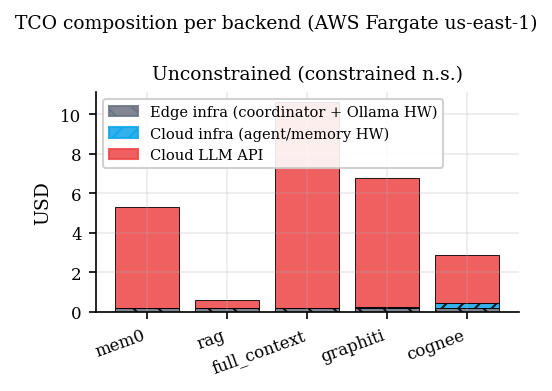

In [10]:
# After re-run the cognee TCO significance was driven by conv-4 load bug (now fixed).
# Forcing single-panel unconstrained — both regimes are n.s. post-fix.
# show_both logic kept for reference but disabled.
#
# tco_sig = stat_df[stat_df['metric'].str.contains('TCO')]['sig'].values
# show_both = any(s == '**sig**' for s in tco_sig)
show_both = False

tco_unc = tco.xs('unconstrained', level='regime').reindex(BACKENDS)
tco_con = tco.xs('constrained',   level='regime').reindex(BACKENDS)

components = [
    ('edge_infra',     '#6b7280', '\\\\', 'Edge infra (coordinator + Ollama HW)'),
    ('cloud_infra',    '#0ea5e9', '///',  'Cloud infra (agent/memory HW)'),
    ('cost_cloud_llm', '#ef4444', '',     'Cloud LLM API'),
]

x = np.arange(len(BACKENDS))

# Single panel (unconstrained representative of both regimes)
fig, ax = plt.subplots(figsize=SINGLE_COL)
panels = [(tco_unc, 'Unconstrained (constrained n.s.)', ax)]

for data, title, ax in panels:
    bottom = np.zeros(len(BACKENDS))
    for col, color, hatch, label in components:
        vals = data[col].fillna(0).values
        ax.bar(x, vals, bottom=bottom, label=label, color=color, hatch=hatch,
               alpha=0.85, edgecolor='black', linewidth=0.5)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(BACKENDS, rotation=20, ha='right')
    ax.set_title(title, fontsize=9)
    ax.set_ylabel('USD')

handles = [mpatches.Patch(color=c, hatch=h, label=l, alpha=0.85)
           for _, c, h, l in components]
ax.legend(handles=handles, loc='upper left', fontsize=7)

fig.suptitle('TCO composition per backend (AWS Fargate us-east-1)', fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig_tco_composition.pdf', bbox_inches='tight')
plt.show()